# پیش‌پردازش داده‌ها

Processed normal image shape: (96, 96, 3)
Processed polyp image shape: (96, 96, 3)


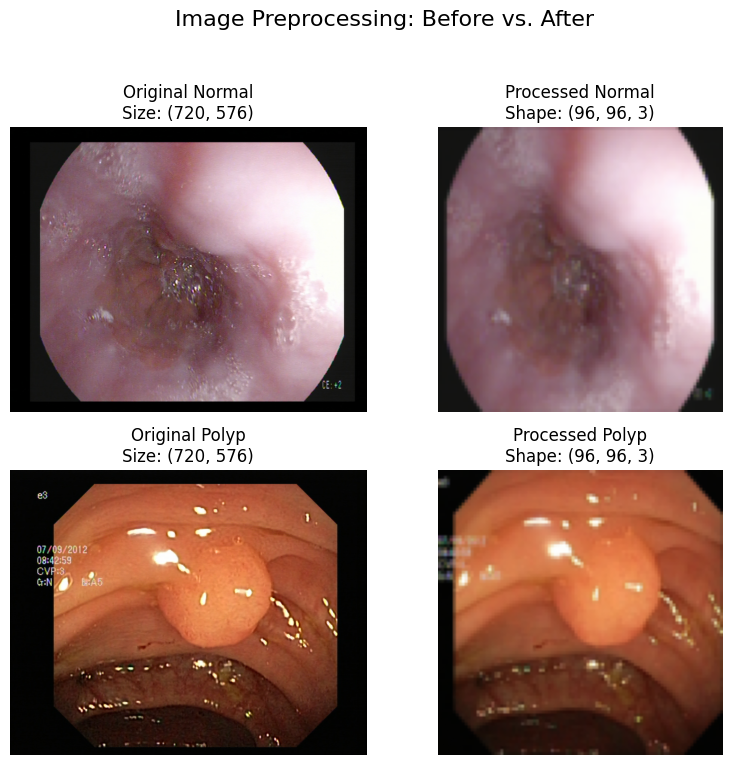


Starting full dataset processing...
Processing images in /kaggle/input/kvasir-dataset/kvasir-dataset/normal-z-line...
Processing images in /kaggle/input/kvasir-dataset/kvasir-dataset/normal-pylorus...
Processing images in /kaggle/input/kvasir-dataset/kvasir-dataset/normal-cecum...
Processing images in /kaggle/input/kvasir-dataset/kvasir-dataset/polyps...

Processing complete.
Normal images saved to: processed/normal
Polyp images saved to: processed/polyp


In [12]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_ROOT=Path("/kaggle/input/kvasir-dataset/kvasir-dataset")

NORMAL_FOLDERS=["normal-z-line","normal-pylorus","normal-cecum"]
POLYP_FOLDER="polyps"

PROCESSED_NORMAL_DIR=Path("processed/normal")
PROCESSED_POLYP_DIR=Path("processed/polyp")

PROCESSED_NORMAL_DIR.mkdir(parents=True,exist_ok=True)
PROCESSED_POLYP_DIR.mkdir(parents=True,exist_ok=True)

def process_image(image_path:Path,target_size:int=96):

    img=Image.open(image_path).convert("RGB")

    grayscale_img=img.convert('L')
    mask=grayscale_img.point(lambda p: 255 if p > 15 else 0, '1')
    
    bbox=mask.getbbox()
    
    if bbox:
        img_cropped=img.crop(bbox)
    else:
        img_cropped=img


    img_resized=img_cropped.resize((target_size,target_size),Image.Resampling.BILINEAR)

    img_array=np.array(img_resized)/255.0

    img_processed=img_array.astype(np.float32)

    return img,img_processed


try:
    normal_image_path=next((DATASET_ROOT/NORMAL_FOLDERS[0]).glob('*.jpg'))
    polyp_image_path=next((DATASET_ROOT/POLYP_FOLDER).glob('*.jpg'))
except StopIteration:
    print("Error: Could not find sample images. Please check your dataset path and folder names.")
    exit()

original_normal_img,processed_normal_array=process_image(normal_image_path)
print(f"Processed normal image shape: {processed_normal_array.shape}")

original_polyp_img,processed_polyp_array=process_image(polyp_image_path)
print(f"Processed polyp image shape: {processed_polyp_array.shape}")


fig,axes=plt.subplots(2,2,figsize=(8,8))
fig.suptitle("Image Preprocessing: Before vs. After",fontsize=16)

axes[0,0].imshow(original_normal_img)
axes[0,0].set_title(f"Original Normal\nSize: {original_normal_img.size}")
axes[0,0].axis('off')

axes[0,1].imshow(processed_normal_array)
axes[0,1].set_title(f"Processed Normal\nShape: {processed_normal_array.shape}")
axes[0,1].axis('off')

axes[1,0].imshow(original_polyp_img)
axes[1,0].set_title(f"Original Polyp\nSize: {original_polyp_img.size}")
axes[1,0].axis('off')

axes[1,1].imshow(processed_polyp_array)
axes[1,1].set_title(f"Processed Polyp\nShape: {processed_polyp_array.shape}")
axes[1,1].axis('off')

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


print("\nStarting full dataset processing...")

for folder_name in NORMAL_FOLDERS:
    source_path=DATASET_ROOT/folder_name
    if not source_path.exists():
        print(f"Warning: Directory not found, skipping: {source_path}")
        continue
    
    print(f"Processing images in {source_path}...")
    for image_path in source_path.glob('*.jpg'):
        _, processed_array=process_image(image_path)
        output_filename=PROCESSED_NORMAL_DIR/ f"{image_path.stem}.npy"
        np.save(output_filename,processed_array)

polyp_source_path=DATASET_ROOT/POLYP_FOLDER
print(f"Processing images in {polyp_source_path}...")
if polyp_source_path.exists():
    for image_path in polyp_source_path.glob('*.jpg'):
        _, processed_array=process_image(image_path)
        output_filename=PROCESSED_POLYP_DIR/ f"{image_path.stem}.npy"
        np.save(output_filename,processed_array)

print("\nProcessing complete.")
print(f"Normal images saved to: {PROCESSED_NORMAL_DIR}")
print(f"Polyp images saved to: {PROCESSED_POLYP_DIR}")

# طراحی معماری EndoVAE

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Input, Flatten, Dense, Reshape, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

INPUT_SHAPE=(96,96,3)
LATENT_DIM=6


encoder_inputs=Input(shape=INPUT_SHAPE, name='encoder_input')
x=Conv2D(16,kernel_size=3,activation='relu',strides=1,padding='same')(encoder_inputs)
x=Conv2D(32,kernel_size=3,activation='relu',strides=1,padding='same')(x)
x=Conv2D(32,kernel_size=3,activation='relu',strides=2,padding='same')(x)
x=Conv2D(64,kernel_size=3,activation='relu',strides=2,padding='same')(x)
x=Conv2D(128,kernel_size=3,activation='relu',strides=1,padding='same')(x)
x=Conv2D(256,kernel_size=3,activation='relu',strides=2,padding='same')(x)
shape_before_flattening=K.int_shape(x)
x=Flatten()(x)
x=Dense(256,activation='relu',name='encoder_dense_256')(x)
z_mean=Dense(LATENT_DIM,name='z_mean')(x)
z_log_var=Dense(LATENT_DIM,name='z_log_var')(x)

def sample_z(args):
    z_mean, z_log_var=args
    batch_size=K.shape(z_mean)[0]
    dims=K.int_shape(z_mean)[1]
    epsilon=K.random_normal(shape=(batch_size,dims))
    return z_mean+K.exp(0.5*z_log_var)*epsilon

z=Lambda(sample_z, output_shape=(LATENT_DIM,), name='z_sampling')([z_mean, z_log_var])
encoder=Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
print("--- Encoder Summary ---")
encoder.summary()

decoder_inputs=Input(shape=(LATENT_DIM,),name='decoder_input')
x=Dense(shape_before_flattening[1]*shape_before_flattening[2]*shape_before_flattening[3],activation='relu')(decoder_inputs)
x=Reshape(shape_before_flattening[1:])(x)
x=Conv2DTranspose(256,kernel_size=3,activation='relu',strides=2,padding='same')(x)
x=Conv2D(128,kernel_size=3,activation='relu',strides=1,padding='same')(x)
x=Conv2DTranspose(64,kernel_size=3,activation='relu',strides=2,padding='same')(x)
x=Conv2D(64,kernel_size=3,activation='relu',strides=1,padding='same')(x)
x=Conv2DTranspose(32, kernel_size=3, activation='relu', strides=2, padding='same')(x)
x=Conv2D(32, kernel_size=3, activation='relu', strides=1, padding='same')(x)

decoder_outputs=Conv2D(3, kernel_size=3, activation='sigmoid', padding='same', name='decoder_output')(x)

decoder=Model(decoder_inputs, decoder_outputs, name='decoder')
print("\n--- Decoder Summary ---")
decoder.summary()


# --- VAE CLASS ---
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder=encoder
        self.decoder=decoder
        self.total_loss_tracker=tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker=tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker=tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z=self.encoder(data)
            reconstruction=self.decoder(z)
            
            # Reconstruction Loss
            reconstruction_loss=tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )
            
            # KL Divergence Loss
            kl_loss=-0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss=tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            
            # Total VAE Loss
            total_loss=reconstruction_loss + kl_loss
            
        grads=tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


vae=VAE(encoder, decoder)

vae.compile(optimizer='adam')
print("\n--- Full VAE Summary (Compiled) ---")
vae.build((None, 96, 96, 3))
vae.summary()

--- Encoder Summary ---


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ encoder_input             │ (None, 96, 96, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_27 (Conv2D)        │ (None, 96, 96, 16)     │            448 │ encoder_input[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_28 (Conv2D)        │ (None, 96, 96, 32)     │          4,640 │ conv2d_27[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_29 (Conv2D)        │ (None, 48, 48, 32)     │          9,248 │ conv2d_28[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_30 (Conv2D)        │ (None, 24, 24, 64)     │         18,496 │ conv2d_29[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_31 (Conv2D)        │ (None, 24, 24, 128)    │         73,856 │ conv2d_30[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_32 (Conv2D)        │ (None, 12, 12, 256)    │        295,168 │ conv2d_31[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_3 (Flatten)       │ (None, 36864)          │              0 │ conv2d_32[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ encoder_dense_256 (Dense) │ (None, 256)            │      9,437,440 │ flatten_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ z_mean (Dense)            │ (None, 6)              │          1,542 │ encoder_dense_256[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ z_log_var (Dense)         │ (None, 6)              │          1,542 │ encoder_dense_256[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ z_sampling (Lambda)       │ (None, 6)              │              0 │ z_mean[0][0],          │
│                           │                        │                │ z_log_var[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 9,842,380 (37.55 MB)

 Trainable params: 9,842,380 (37.55 MB)

...

Model: "vae_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ encoder (Functional)                 │ ((None, 6), (None, 6),      │       9,842,380 │
│                                      │ (None, 6))                  │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder (Functional)                 │ (None, 96, 96, 3)           │       1,282,467 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,124,847 (42.44 MB)

 Trainable params: 11,124,847 (42.44 MB)

 Non-trainable params: 0 (0.00 B)

# تعریف توابع هزینه

# روند آموزش مدل

--- Setting up hyperparameters and data pipeline ---
Loaded 1500 normal images.
Training data size: 1350
Validation data size: 150

--- Starting Training for 800 epochs ---
Epoch 5/800:
  Train -> total: 5803.48, recon: 5796.28, kl: 7.20
  Val   -> total: 5728.49, recon: 5720.42, kl: 8.08
Epoch 10/800:
  Train -> total: 5546.29, recon: 5529.02, kl: 17.26
  Val   -> total: 5487.74, recon: 5466.94, kl: 20.80
Epoch 15/800:
  Train -> total: 5344.84, recon: 5329.20, kl: 15.64
  Val   -> total: 5322.26, recon: 5302.57, kl: 19.69
Epoch 20/800:
  Train -> total: 5251.83, recon: 5235.18, kl: 16.65
  Val   -> total: 5245.50, recon: 5229.27, kl: 16.23
Epoch 25/800:
  Train -> total: 5232.62, recon: 5215.81, kl: 16.81
  Val   -> total: 5221.88, recon: 5205.37, kl: 16.51
Epoch 30/800:
  Train -> total: 5202.55, recon: 5185.94, kl: 16.61
  Val   -> total: 5217.97, recon: 5199.98, kl: 18.00
Epoch 35/800:
  Train -> total: 5201.47, recon: 5185.07, kl: 16.40
  Val   -> total: 5205.63, recon: 5188.99, 

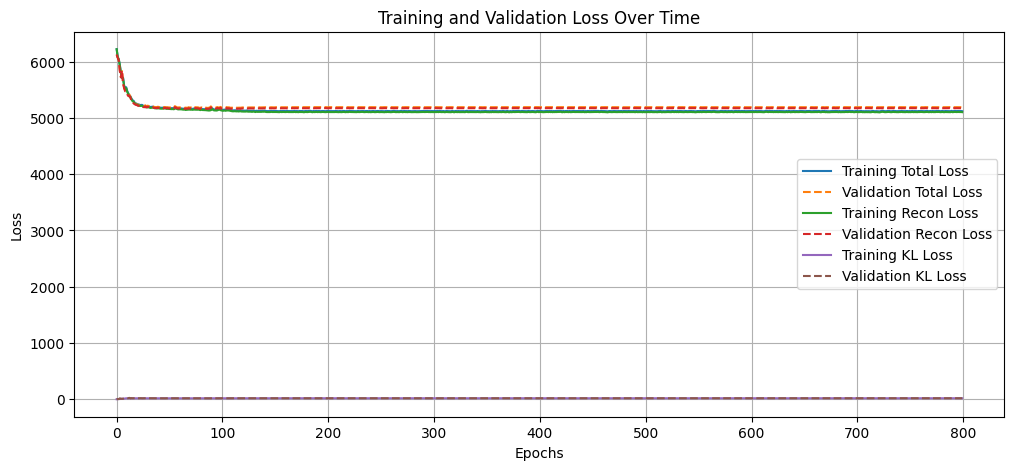

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


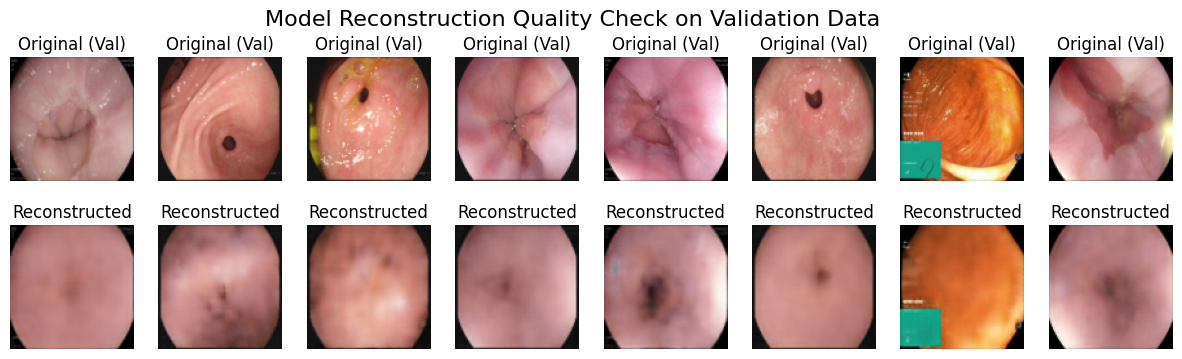

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, Callback
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time



class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder=encoder
        self.decoder=decoder
        self.total_loss_tracker=tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker=tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker=tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z=self.encoder(data)
            reconstruction=self.decoder(z)
            
            reconstruction_loss=tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )
            kl_loss=-0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss=tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss=reconstruction_loss + kl_loss
            
        grads=tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        z_mean, z_log_var, z=self.encoder(data)
        reconstruction=self.decoder(z)
        
        reconstruction_loss=tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(data, reconstruction),
                axis=(1, 2)
            )
        )
        kl_loss=-0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss=tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss=reconstruction_loss + kl_loss
        
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {m.name: m.result() for m in self.metrics}

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)
        return reconstructed

print("--- Setting up hyperparameters and data pipeline ---")

INITIAL_LEARNING_RATE=1e-3
BATCH_SIZE=128
EPOCHS=800
REPORT_FREQ=5

PROCESSED_NORMAL_DIR=Path("processed/normal")
all_normal_images=[np.load(f) for f in PROCESSED_NORMAL_DIR.glob('*.npy')]
np.random.shuffle(all_normal_images)
all_normal_data=np.stack(all_normal_images, axis=0)
print(f"Loaded {all_normal_data.shape[0]} normal images.")

split_index=int(len(all_normal_data) * 0.9)
train_data=all_normal_data[:split_index]
val_data=all_normal_data[split_index:]
print(f"Training data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")

train_dataset=tf.data.Dataset.from_tensor_slices(train_data).shuffle(buffer_size=len(train_data)).batch(BATCH_SIZE)
val_dataset=tf.data.Dataset.from_tensor_slices(val_data).batch(BATCH_SIZE)

vae=VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE))

print(f"\n--- Starting Training for {EPOCHS} epochs ---")

start_time=time.time()

class ReportingCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % REPORT_FREQ == 0:
            print(f"Epoch {epoch + 1}/{self.params['epochs']}:")
            print(f"  Train -> total: {logs['total_loss']:.2f}, "
                  f"recon: {logs['reconstruction_loss']:.2f}, "
                  f"kl: {logs['kl_loss']:.2f}")
            print(f"  Val   -> total: {logs['val_total_loss']:.2f}, "
                  f"recon: {logs['val_reconstruction_loss']:.2f}, "
                  f"kl: {logs['val_kl_loss']:.2f}")

lr_scheduler=ReduceLROnPlateau(
    monitor='val_total_loss',
    factor=0.3,
    patience=20,
    min_lr=1e-7,
    verbose=1
)

history=vae.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[lr_scheduler, ReportingCallback()],
    verbose=0 
)

total_training_time=time.time() - start_time
print(f"\n--- Training Finished in {total_training_time:.2f} seconds ---")

print("\n--- Generating plots and sample reconstructions ---")
plt.figure(figsize=(12, 5))
plt.plot(history.history['total_loss'], label='Training Total Loss')
plt.plot(history.history['val_total_loss'], label='Validation Total Loss', linestyle='--')
plt.plot(history.history['reconstruction_loss'], label='Training Recon Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Validation Recon Loss', linestyle='--')
plt.plot(history.history['kl_loss'], label='Training KL Loss')
plt.plot(history.history['val_kl_loss'], label='Validation KL Loss', linestyle='--')
plt.title('Training and Validation Loss Over Time')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

num_samples_to_show=8
sample_images=next(iter(val_dataset.take(1)))[:num_samples_to_show]
reconstructed_images=vae.predict(sample_images)

plt.figure(figsize=(15, 4))
for i in range(num_samples_to_show):
    ax=plt.subplot(2, num_samples_to_show, i + 1)
    plt.imshow(sample_images[i])
    plt.title("Original (Val)")
    plt.axis("off")

    ax=plt.subplot(2, num_samples_to_show, i + 1 + num_samples_to_show)
    plt.imshow(reconstructed_images[i])
    plt.title("Reconstructed")
    plt.axis("off")
plt.suptitle("Model Reconstruction Quality Check on Validation Data", fontsize=16)
plt.show()


# تولید و بازسازی کیفی

---Generating new images from random latent vectors---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step


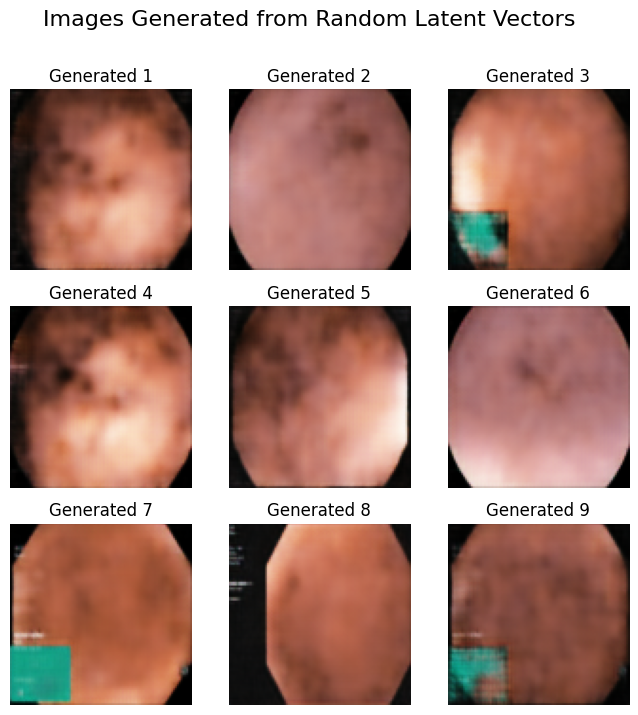

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


print("---Generating new images from random latent vectors---")

num_images_to_generate=9

random_latent_vectors=tf.random.normal(shape=(num_images_to_generate,LATENT_DIM))

generated_images=decoder.predict(random_latent_vectors)

plt.figure(figsize=(8,8))
for i in range(num_images_to_generate):
    ax=plt.subplot(3,3,i+1)
    plt.imshow(generated_images[i])
    plt.title(f"Generated {i+1}")
    plt.axis("off")

plt.suptitle("Images Generated from Random Latent Vectors", fontsize=16)
plt.show()



--- 5-2: Reconstructing abnormal (polyp) images ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


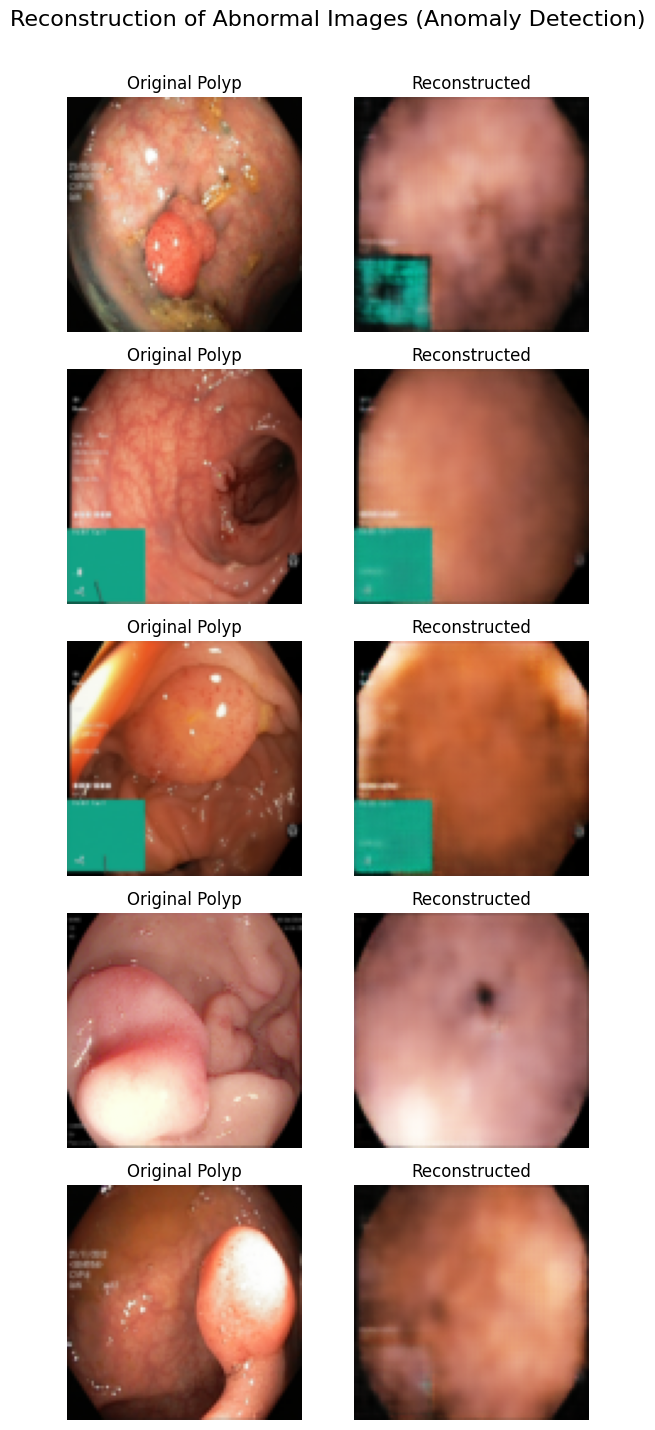

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random


print("\n Reconstructing abnormal (polyp) images ")

PROCESSED_POLYP_DIR=Path("processed/polyp")
polyp_files=list(PROCESSED_POLYP_DIR.glob('*.npy'))

num_samples_to_show=5

if len(polyp_files) < num_samples_to_show:
    print(f"Error: Not enough polyp images found in {PROCESSED_POLYP_DIR}")
else:
    polyp_images_list=[np.load(f) for f in polyp_files[:num_samples_to_show]]
    polyp_batch=np.stack(polyp_images_list, axis=0)


    reconstructed_polyp_images=vae.predict(polyp_batch)


    plt.figure(figsize=(6, 15))
    for i in range(num_samples_to_show):

        ax=plt.subplot(num_samples_to_show, 2, i * 2 + 1)
        plt.imshow(polyp_batch[i])
        plt.title("Original Polyp")
        plt.axis("off")

        ax=plt.subplot(num_samples_to_show, 2, i * 2 + 2)
        plt.imshow(reconstructed_polyp_images[i])
        plt.title("Reconstructed")
        plt.axis("off")
        
    plt.suptitle("Reconstruction of Abnormal Images (Anomaly Detection)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) 
    plt.show()


# ارزیابی عددی

In [18]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pathlib import Path
import random


print("\n Quantitative Evaluation on Abnormal (Polyp) Images ")

PROCESSED_POLYP_DIR=Path("processed/polyp")
all_polyp_files=list(PROCESSED_POLYP_DIR.glob('*.npy'))

num_eval_images=50

if len(all_polyp_files) < num_eval_images:
    print(f"Error: Not enough polyp images found. Found {len(all_polyp_files)}, need {num_eval_images}.")
else:
    random_files=random.sample(all_polyp_files, num_eval_images)
    
    original_images_list=[np.load(f) for f in random_files]
    original_images_batch=np.stack(original_images_list, axis=0)
    
    print(f"Loaded {len(original_images_batch)} random polyp images for evaluation.")

    regenerated_images_batch = vae.predict(original_images_batch)
    print("Regenerated images from the VAE.")

    psnr_scores=[]
    ssim_scores=[]

    for i in range(num_eval_images):
        original_img=original_images_batch[i]
        regenerated_img=regenerated_images_batch[i]

        original_tensor=tf.convert_to_tensor(original_img, dtype=tf.float32)
        regenerated_tensor=tf.convert_to_tensor(regenerated_img, dtype=tf.float32)

        psnr=tf.image.psnr(original_tensor,regenerated_tensor,max_val=1.0)
        psnr_scores.append(psnr.numpy())

        ssim=tf.image.ssim(original_tensor,regenerated_tensor,max_val=1.0)
        ssim_scores.append(ssim.numpy())

    print("Calculated PSNR and SSIM for all 50 images.")


    psnr_mean=np.mean(psnr_scores)
    psnr_std=np.std(psnr_scores)

    ssim_mean=np.mean(ssim_scores)
    ssim_std=np.std(ssim_scores)

    results_data ={
        'Metric': ['PSNR', 'SSIM'],
        'Mean': [psnr_mean, ssim_mean],
        'Standard Deviation': [psnr_std, ssim_std]
    }
    results_df=pd.DataFrame(results_data)
    
    print("\n--- Evaluation Results ---")
    print(results_df.to_string(index=False))




--- Quantitative Evaluation on Abnormal (Polyp) Images ---
Loaded 50 random polyp images for evaluation.
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
Regenerated images from the VAE.
Calculated PSNR and SSIM for all 50 images.

--- Evaluation Results ---
Metric      Mean  Standard Deviation
  PSNR 17.382328            2.925426
  SSIM  0.482061            0.112238


In [19]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pathlib import Path
import random


print("\n--- Quantitative Evaluation on Abnormal (Polyp) Images ---")

PROCESSED_POLYP_DIR=Path("processed/polyp")
all_polyp_files=list(PROCESSED_POLYP_DIR.glob('*.npy'))

num_eval_images=50

if len(all_polyp_files) < num_eval_images:
    print(f"Error: Not enough polyp images found. Found {len(all_polyp_files)}, need {num_eval_images}.")
else:
    random_files=random.sample(all_polyp_files, num_eval_images)
    
    original_images_list=[np.load(f) for f in random_files]
    original_images_batch=np.stack(original_images_list, axis=0)
    
    print(f"Loaded {len(original_images_batch)} random polyp images for evaluation.")

    regenerated_images_batch=vae.predict(original_images_batch)
    print("Regenerated images from the VAE.")

    psnr_scores=[]
    ssim_scores=[]

    print("\n--- Per-Image Evaluation Results ---")
    for i in range(num_eval_images):
        original_img=original_images_batch[i]
        regenerated_img=regenerated_images_batch[i]

        original_tensor=tf.convert_to_tensor(original_img, dtype=tf.float32)
        regenerated_tensor=tf.convert_to_tensor(regenerated_img, dtype=tf.float32)

        psnr=tf.image.psnr(original_tensor, regenerated_tensor, max_val=1.0)
        psnr_scores.append(psnr.numpy())

        ssim=tf.image.ssim(original_tensor, regenerated_tensor, max_val=1.0)
        ssim_scores.append(ssim.numpy())
        
        print(f"Image {i+1:02d}: PSNR={psnr.numpy():.4f}, SSIM={ssim.numpy():.4f}")


    psnr_mean=np.mean(psnr_scores)
    psnr_var=np.var(psnr_scores) 

    ssim_mean=np.mean(ssim_scores)
    ssim_var=np.var(ssim_scores) 

    results_data={
        'Metric': ['PSNR', 'SSIM'],
        'Mean': [psnr_mean, ssim_mean],
        'Variance': [psnr_var, ssim_var] 
    }
    results_df=pd.DataFrame(results_data)
    
    print("\n--- Aggregate Evaluation Results ---")
    print(results_df.to_string(index=False))




--- Quantitative Evaluation on Abnormal (Polyp) Images ---
Loaded 50 random polyp images for evaluation.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Regenerated images from the VAE.

--- Per-Image Evaluation Results ---
Image 01: PSNR=15.6461, SSIM=0.5299
Image 02: PSNR=17.2239, SSIM=0.4464
Image 03: PSNR=17.2402, SSIM=0.4379
Image 04: PSNR=21.1119, SSIM=0.5958
Image 05: PSNR=20.3838, SSIM=0.5701
Image 06: PSNR=16.4248, SSIM=0.4579
Image 07: PSNR=12.8407, SSIM=0.3247
Image 08: PSNR=20.6804, SSIM=0.6499
Image 09: PSNR=12.9734, SSIM=0.2964
Image 10: PSNR=15.7074, SSIM=0.3817
Image 11: PSNR=18.0093, SSIM=0.4497
Image 12: PSNR=18.4001, SSIM=0.5120
Image 13: PSNR=19.6473, SSIM=0.5869
Image 14: PSNR=24.2810, SSIM=0.6938
Image 15: PSNR=13.4442, SSIM=0.3789
Image 16: PSNR=17.3288, SSIM=0.4164
Image 17: PSNR=14.0402, SSIM=0.5591
Image 18: PSNR=15.0109, SSIM=0.2983
Image 19: PSNR=16.7524, SSIM=0.3651
Image 20: PSNR=14.7314, SSIM=0.3670
Image 21: PSNR=14.8125, SSIM=0.2745
Image 22: PSNR=18.1714, SSIM=

# امتیازی

--- Preparing Dataset: Real vs. Regenerated Polyps ---
Loaded 200 real polyp images.
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Generated 200 regenerated polyp images.
Total data: 400 images.
Training set size: 320 images.
Testing set size: 80 images.

--- Building and Training the CNN Classifier ---


Model: "polyp_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)                   │ (None, 94, 94, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 47, 47, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 47, 47, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_37 (Conv2D)                   │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,984,577 (15.20 MB)

 Trainable params: 3,984,577 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.4933 - loss: 1.1192 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5222 - loss: 0.6903 - val_accuracy: 0.5000 - val_loss: 0.6834
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5125 - loss: 0.6896 - val_accuracy: 0.6500 - val_loss: 0.6801
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5995 - loss: 0.6567 - val_accuracy: 0.8250 - val_loss: 0.6282
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6787 - loss: 0.6113 - val_accuracy: 0.7375 - val_loss: 0.5864
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7556 - loss: 0.5250 - val_accuracy: 0.8375 - val_loss: 0.4498
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7875 - loss: 0.4792 - val_accuracy: 0.7625 - val_loss: 0.4886
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7711 - loss: 0.4611 - val_accuracy: 0.9375 - 

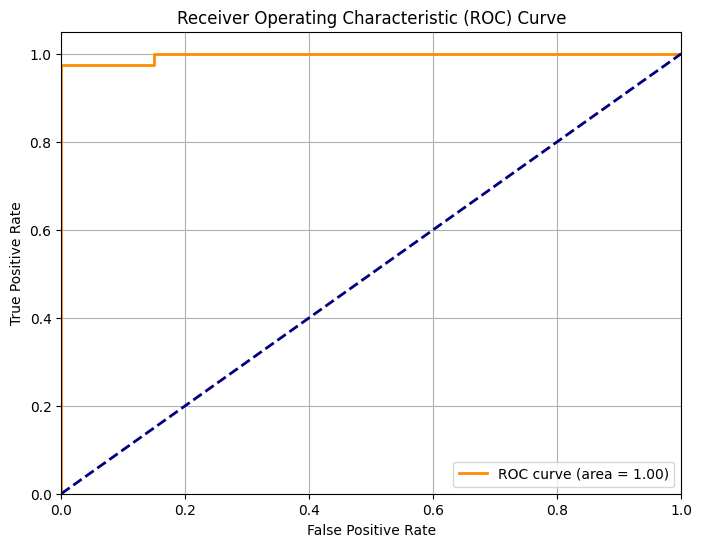

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

print("--- Preparing Dataset: Real vs. Regenerated Polyps ---")

PROCESSED_POLYP_DIR=Path("processed/polyp")
all_polyp_files=list(PROCESSED_POLYP_DIR.glob('*.npy'))
num_images=200

if len(all_polyp_files) < num_images:
    print(f"Error: Not enough polyp images found. Found {len(all_polyp_files)}, need {num_images}.")
else:
    random_files=random.sample(all_polyp_files, num_images)
    real_polyps=[np.load(f) for f in random_files]
    real_polyps_batch=np.stack(real_polyps, axis=0)
    print(f"Loaded {len(real_polyps_batch)} real polyp images.")

    regenerated_polyps_batch=vae.predict(real_polyps_batch)
    print(f"Generated {len(regenerated_polyps_batch)} regenerated polyp images.")


    real_labels=np.ones(num_images)
    regenerated_labels=np.zeros(num_images)

    X_data=np.concatenate([real_polyps_batch, regenerated_polyps_batch], axis=0)
    y_data=np.concatenate([real_labels, regenerated_labels], axis=0)


    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.20, shuffle=True, stratify=y_data, random_state=42
    )
    print(f"Total data: {len(X_data)} images.")
    print(f"Training set size: {len(X_train)} images.")
    print(f"Testing set size: {len(X_test)} images.")


print("\n--- Building and Training the CNN Classifier ---")

classifier=Sequential([
    Input(shape=(96, 96, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') 
], name="polyp_classifier")

classifier.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

classifier.summary()

early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history=classifier.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

print("\n--- Evaluating Classifier Performance ---")

y_pred_proba=classifier.predict(X_test).ravel()
# Convert probabilities to class labels (0 or 1)
y_pred_class=(y_pred_proba > 0.5).astype(int)

accuracy=accuracy_score(y_test, y_pred_class)
fpr, tpr, thresholds=roc_curve(y_test, y_pred_proba)
roc_auc=auc(fpr, tpr)

print(f"\nFinal Test Accuracy: {accuracy * 100:.2f}%")
print(f"Final Test AUC: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
